In [17]:
import pandas as pd
from tqdm import tqdm
import wptools
from get_article_links import get_article_links_wikitext 

In [18]:
# import df
df = pd.read_csv("../data/world_leaders_with_gender_wikidataid.csv")
df.head()

,person,position,country,wikidata_id,gender
0,Hibatullah Akhundzada,Supreme Leader,Afghanistan,Q24237654,male
1,Edi Rama,Prime Minister,Albania,Q316901,male
2,Abdelmadjid Tebboune,President,Algeria,Q2821166,male
3,João Lourenço,President,Angola,Q28650390,male
4,Rodney Williams,Governor-General,Antigua and Barbuda,Q17566330,male


In [19]:
# function to fetch attributes from Wikidata for a given person or wikidata ID
def get_attributes(person=None, wikidata_id=None, max_links=1000):
    """
    Fetch Wikipedia attributes using person name or Wikidata ID:
    - page_length: number of words in article
    - num_references: number of internal links
    - num_languages: number of language links
    """
    try:
        if person:
            page = wptools.page(person)
        elif wikidata_id:
            page = wptools.page(wikidata_id, silent=True)  # QID
        else:
            return {"page_length": None, "num_references": None, "num_languages": None}
        page.get_query(show=False)
        page.get_more(show=False)

        # page length (words)
        word_count = len(page.data.get("extract", "").split())

        # number of internal links
        links = get_article_links_wikitext(person if person else wikidata_id, limit=max_links)
        num_references = len(links)

        # number of language versions
        num_languages = len(page.data.get("languages", {}))

        return {"page_length": word_count, "num_references": num_references, "num_languages": num_languages}

    except Exception as e:
        print(f"Failed for person='{person}', wikidata_id='{wikidata_id}': {e}")
        return {"page_length": None, "num_references": None, "num_languages": None}


# fetch attributes for each person in the dataframe
attributes_list = []
for idx, row in tqdm(df.iterrows(), total=len(df), desc="Fetching Wikipedia attributes"):
    person = row.get('person')
    attrs = get_attributes(person)
    attributes_list.append(attrs)


# create a new dataframe with the attributes
attributes_df = pd.DataFrame(attributes_list)
df_final = pd.concat([df, attributes_df], axis=1)
df_final.head() 

Fetching Wikipedia attributes:   0%|          | 0/207 [00:00<?, ?it/s]en.wikipedia.org (query) Hibatullah Akhundzada
en.wikipedia.org (query) Hibatullah Akhundzada (&plcontinue=50633...
en.wikipedia.org (querymore) 50633776
en.wikipedia.org (querymore) 50633776 (&blcontinue=0|64737726)
Fetching Wikipedia attributes:   0%|          | 1/207 [00:03<10:31,  3.07s/it]en.wikipedia.org (query) Edi Rama
en.wikipedia.org (query) Edi Rama (&plcontinue=277805|0|Sara_Zaafarani)
en.wikipedia.org (imageinfo) File:Srečanje predsednika vlade Robe...
en.wikipedia.org (querymore) 277805
en.wikipedia.org (querymore) 277805 (&blcontinue=0|49902213)
en.wikipedia.org (querymore) 277805 (&blcontinue=0|80238147)
Fetching Wikipedia attributes:   1%|          | 2/207 [00:06<11:41,  3.42s/it]en.wikipedia.org (query) Abdelmadjid Tebboune
en.wikipedia.org (query) Abdelmadjid Tebboune (&plcontinue=541339...
en.wikipedia.org (imageinfo) File:Abdelmadjid Tebboune in 2024 (c...
en.wikipedia.org (querymore) 54133968
en

Failed for person='Javier Milei', wikidata_id='None': https://en.wikipedia.org/w/api.php?action=query&exintro&formatversion=2&inprop=url|watchers&list=random&pithumbsize=240&pllimit=500&ppprop=disambiguation|wikibase_item&prop=extracts|info|links|pageassessments|pageimages|pageprops|pageterms|redirects&redirects&rdlimit=500&rnlimit=1&rnnamespace=0&titles=Javier%20Milei&plcontinue=56599840|0|Hernán_Lombardi


en.wikipedia.org (query) Nikol Pashinyan (&plcontinue=17897961|0|...
en.wikipedia.org (imageinfo) File:Nikol Pashinyan at the 2025 SCO...
en.wikipedia.org (querymore) 17897961
en.wikipedia.org (querymore) 17897961 (&blcontinue=0|54994162)
en.wikipedia.org (querymore) 17897961 (&blcontinue=0|76508915)
Fetching Wikipedia attributes:   4%|▍         | 8/207 [00:18<07:14,  2.18s/it]en.wikipedia.org (query) Sam Mostyn
en.wikipedia.org (imageinfo) File:Sam Mostyn 2024.jpg
en.wikipedia.org (querymore) 69373896
Fetching Wikipedia attributes:   4%|▍         | 9/207 [00:20<06:43,  2.04s/it]en.wikipedia.org (query) Anthony Albanese
en.wikipedia.org (query) Anthony Albanese (&plcontinue=556745|0|G...
en.wikipedia.org (query) Anthony Albanese (&plcontinue=556745|0|R...
en.wikipedia.org (imageinfo) File:Anthony Albanese portrait (re-c...
en.wikipedia.org (querymore) 556745
en.wikipedia.org (querymore) 556745 (&blcontinue=0|7062601)
en.wikipedia.org (querymore) 556745 (&blcontinue=0|47192712)
en.wikip

Failed for person='Rodrigo Paz', wikidata_id='None': https://en.wikipedia.org/w/api.php?action=query&exintro&formatversion=2&inprop=url|watchers&list=random&pithumbsize=240&pllimit=500&ppprop=disambiguation|wikibase_item&prop=extracts|info|links|pageassessments|pageimages|pageprops|pageterms|redirects&redirects&rdlimit=500&rnlimit=1&rnnamespace=0&titles=Rodrigo%20Paz&plcontinue=69731047|0|Phạm_Minh_Chính


en.wikipedia.org (query) Christian Schmidt (&plcontinue=39499479|...
en.wikipedia.org (query) Christian Schmidt (&plcontinue=39499479|...
en.wikipedia.org (query) Christian Schmidt (&plcontinue=39499479|...
en.wikipedia.org (query) Christian Schmidt (&plcontinue=39499479|...
en.wikipedia.org (query) Christian Schmidt (&plcontinue=39499479|...
Fetching Wikipedia attributes:  12%|█▏        | 24/207 [01:02<05:30,  1.81s/it]en.wikipedia.org (query) Duma Boko


...

Failed for person='Recep Tayyip Erdoğan', wikidata_id='None': https://en.wikipedia.org/w/api.php?action=query&exintro&formatversion=2&inprop=url|watchers&list=random&pithumbsize=240&pllimit=500&ppprop=disambiguation|wikibase_item&prop=extracts|info|links|pageassessments|pageimages|pageprops|pageterms|redirects&redirects&rdlimit=500&rnlimit=1&rnnamespace=0&titles=Recep%20Tayyip%20Erdo%C4%9Fan&plcontinue=376619|0|Behiç_Çelik


en.wikipedia.org (imageinfo) File:White House visit by C5 Central...
en.wikipedia.org (querymore) 57581379
Fetching Wikipedia attributes:  88%|████████▊ | 182/207 [09:10<00:47,  1.90s/it]en.wikipedia.org (query) Tofiga Vaevalu Falani
en.wikipedia.org (imageinfo) File:Tofiga Vaevalu Falani 2021.jpg
en.wikipedia.org (querymore) 69036123
Fetching Wikipedia attributes:  88%|████████▊ | 183/207 [09:11<00:41,  1.74s/it]en.wikipedia.org (query) Feleti Teo
en.wikipedia.org (imageinfo) File:Feleti Teo 2024 Taiwan.jpg
en.wikipedia.org (querymore) 19315200
Fetching Wikipedia attributes:  89%|████████▉ | 184/207 [09:13<00:39,  1.72s/it]en.wikipedia.org (query) Yoweri Museveni
en.wikipedia.org (query) Yoweri Museveni (&plcontinue=293409|0|Po...
en.wikipedia.org (imageinfo) File:Yoweri Museveni 2024.jpg
en.wikipedia.org (querymore) 293409
en.wikipedia.org (querymore) 293409 (&blcontinue=1|10955877)
en.wikipedia.org (querymore) 293409 (&blcontinue=0|45560078)
en.wikipedia.org (querymore) 293409 (&blc

Failed for person='Donald Trump', wikidata_id='None': Hit REQUEST_LIMIT = 50


en.wikipedia.org (query) Yamandú Orsi
en.wikipedia.org (query) Yamandú Orsi (&plcontinue=64719316|4|Cit...
en.wikipedia.org (imageinfo) File:Yamandú Orsi dic 2025.jpg
en.wikipedia.org (querymore) 64719316
en.wikipedia.org (querymore) 64719316 (&blcontinue=0|71882148)
Fetching Wikipedia attributes:  92%|█████████▏| 190/207 [10:32<03:58, 14.05s/it]en.wikipedia.org (query) Shavkat Mirziyoyev
en.wikipedia.org (imageinfo) File:Shavkat Mirziyoyev official por...
en.wikipedia.org (querymore) 399855
en.wikipedia.org (querymore) 399855 (&blcontinue=4|69179847)
Fetching Wikipedia attributes:  92%|█████████▏| 191/207 [10:34<02:49, 10.56s/it]en.wikipedia.org (query) Jotham Napat
en.wikipedia.org (imageinfo) File:Jotham Napat 2019 (cropped).jpg
en.wikipedia.org (querymore) 74730036
Fetching Wikipedia attributes:  93%|█████████▎| 192/207 [10:36<01:57,  7.84s/it]en.wikipedia.org (query) Rashad al-Alimi
en.wikipedia.org (imageinfo) File:Rashad al-Alimi 2022 (cropped).jpg
en.wikipedia.org (querymore) 7

,person,position,country,wikidata_id,gender,page_length,num_references,num_languages
0,Hibatullah Akhundzada,Supreme Leader,Afghanistan,Q24237654,male,312.0,145.0,65.0
1,Edi Rama,Prime Minister,Albania,Q316901,male,171.0,256.0,75.0
2,Abdelmadjid Tebboune,President,Algeria,Q2821166,male,97.0,142.0,69.0
3,João Lourenço,President,Angola,Q28650390,male,179.0,74.0,60.0
4,Rodney Williams,Governor-General,Antigua and Barbuda,Q17566330,male,46.0,40.0,28.0


In [24]:
# check for missing values
print(df_final.isnull().sum())

# drop rows with missing attributes
df_final_clean = df_final.dropna(subset=['page_length', 'num_references', 'num_languages'])
print(f"Final dataset size after dropping missing values: {len(df_final_clean)}")

person             0
position           0
country            0
wikidata_id        0
gender             0
page_length       12
num_references    12
num_languages     12
dtype: int64
Final dataset size after dropping missing values: 195


In [25]:
# save the final dataframe with attributes
df_final_clean.to_csv("../data/world_leaders_final.csv", index=False)

# Visulization

In [33]:
summary = df_final_clean.groupby('gender')[['page_length','num_references','num_languages']].describe()

print(summary)  

       page_length                                                             \
             count        mean         std   min    25%    50%     75%    max   
gender                                                                          
female        26.0  216.807692  153.830561  28.0  110.0  173.0  279.25  580.0   
male         169.0  237.284024  180.801891  23.0   88.0  180.0  347.00  718.0   

       num_references              ...               num_languages             \
                count        mean  ...    75%    max         count       mean   
gender                             ...                                          
female           26.0  148.769231  ...  191.0  566.0          26.0  49.846154   
male            169.0  155.585799  ...  196.0  749.0         169.0  51.218935   

                                                  
              std   min   25%   50%   75%    max  
gender                                            
female  25.753745  17.0  29.5  41.5

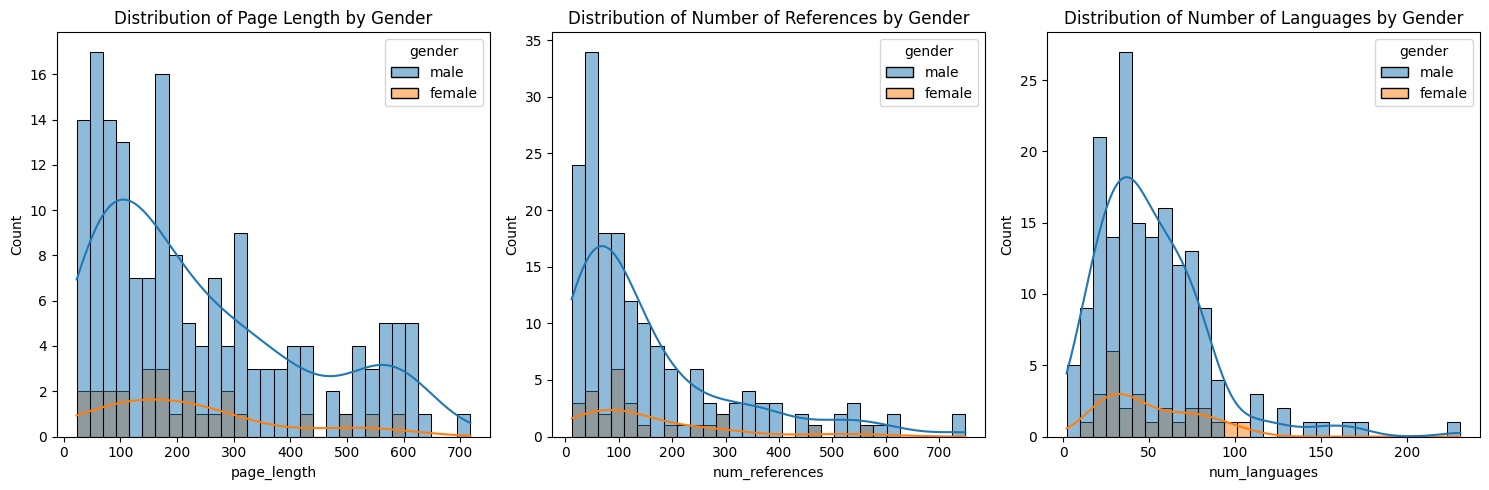

In [ ]:
# leaders visibility visualization
import matplotlib.pyplot as plt
import seaborn as sns

# distribution of page lengths, num of references, and num of languages by gender
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.histplot(df_final_clean, x='page_length', hue='gender', bins=30, kde=True)
plt.title('Distribution of Page Length by Gender')

plt.subplot(1, 3, 2)
sns.histplot(df_final_clean, x='num_references', hue='gender', bins=30, kde=True)
plt.title('Distribution of Number of References by Gender')

plt.subplot(1, 3, 3)
sns.histplot(df_final_clean, x='num_languages', hue='gender', bins=30, kde=True)
plt.title('Distribution of Number of Languages by Gender')
plt.tight_layout()
plt.show()

/var/folders/ph/r90yks3114v80l6g_p8n6yxw0000gn/T/ipykernel_28994/1732241024.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='gender', y='page_length', data=df_final_clean, palette=palette, ax=axes[0])
/var/folders/ph/r90yks3114v80l6g_p8n6yxw0000gn/T/ipykernel_28994/1732241024.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='gender', y='num_references', data=df_final_clean, palette=palette, ax=axes[1])
/var/folders/ph/r90yks3114v80l6g_p8n6yxw0000gn/T/ipykernel_28994/1732241024.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(

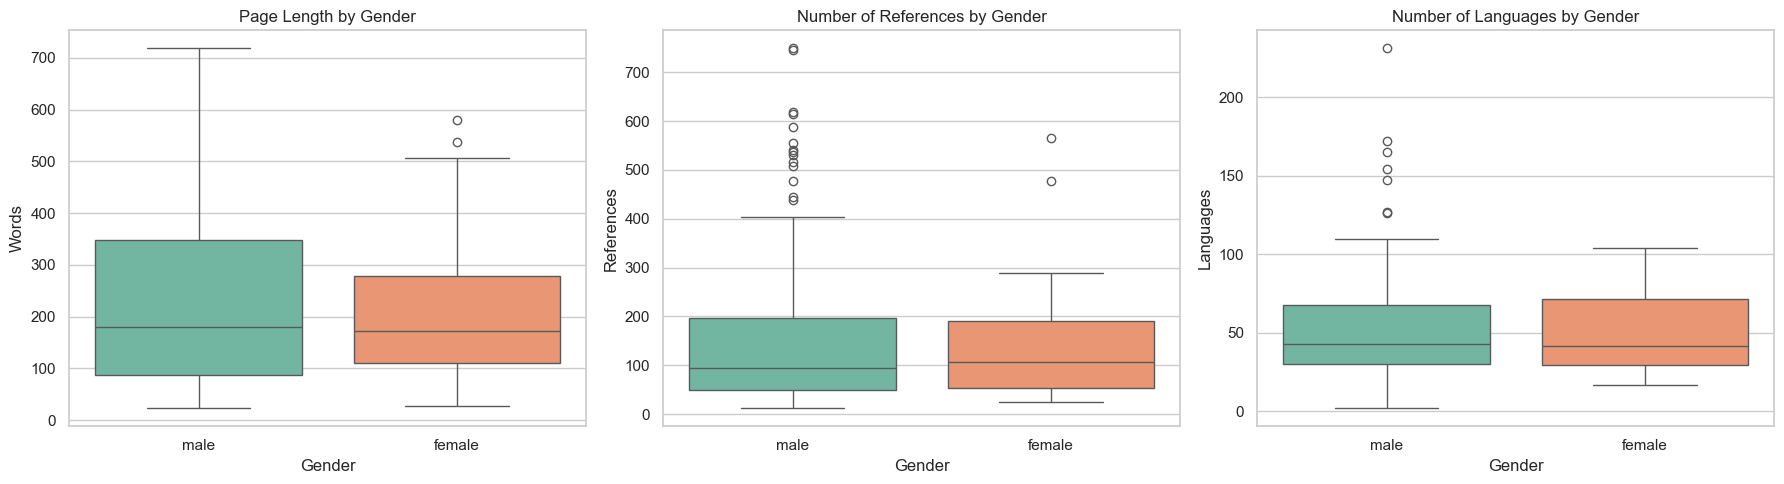

In [ ]:
sns.set(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(18,5))
palette = "Set2"

sns.boxplot(x='gender', y='page_length', data=df_final_clean, palette=palette, ax=axes[0])
axes[0].set_title("Page Length by Gender")
axes[0].set_ylabel("Words")
axes[0].set_xlabel("Gender")

sns.boxplot(x='gender', y='num_references', data=df_final_clean, palette=palette, ax=axes[1])
axes[1].set_title("Number of References by Gender")
axes[1].set_ylabel("References")
axes[1].set_xlabel("Gender")

sns.boxplot(x='gender', y='num_languages', data=df_final_clean, palette=palette, ax=axes[2])
axes[2].set_title("Number of Languages by Gender")
axes[2].set_ylabel("Languages")
axes[2].set_xlabel("Gender")

plt.tight_layout()
plt.show()